# 04 — E-GEO Benchmark-Style Final Tables and Figures (FIXED)

This fixed version reads the standard outputs from notebooks **01**, **02**, and **03**, plus final manuscript tables if the intermediate metric CSVs are not available.

Main fixes:

- Supplementary Table S1 can use `egeo_02_nontrained_baseline_summary.csv` to fill random, lexical, and E5 official-test or cross-model values.
- Supplementary Table S3 recomputes high-vs-low visibility feature profiles from the validation split for the same features used in the feature-importance table, avoiding merge-induced `NaN` values.
- Final CSV/LaTeX tables display unavailable values as `--` instead of `NaN`.


In [1]:
# %pip install -q -U pandas numpy matplotlib

In [2]:
# !pip install -U --force-reinstall matplotlib

## 1. Setup and helper functions

In [3]:
from pathlib import Path
import sys, math, warnings
from textwrap import fill
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

warnings.filterwarnings("ignore")

if "google.colab" in sys.modules:
    from google.colab import drive
    drive.mount("/content/drive")

PROJECT_ROOT = Path("/content/drive/MyDrive/Finance Research/E-GEO-ML")
if not PROJECT_ROOT.exists():
    CWD = Path.cwd().resolve()
    if (CWD / "data").exists() and (CWD / "raw_data").exists():
        PROJECT_ROOT = CWD
    elif (CWD.parent / "data").exists() and (CWD.parent / "raw_data").exists():
        PROJECT_ROOT = CWD.parent
    else:
        PROJECT_ROOT = CWD.parent if CWD.name.lower() == "code" else CWD

DATA_DIR = PROJECT_ROOT / "data"
FIGURES_DIR = PROJECT_ROOT / "figures"
MAIN_FIG_DIR = FIGURES_DIR / "main_benchmark_final"
SUPP_FIG_DIR = FIGURES_DIR / "supplementary_benchmark_final"
RESULTS_DIR = PROJECT_ROOT / "results"
TABLE_DIR = DATA_DIR / "manuscript_tables_benchmark_final"
for d in [DATA_DIR, MAIN_FIG_DIR, SUPP_FIG_DIR, RESULTS_DIR, TABLE_DIR]:
    d.mkdir(parents=True, exist_ok=True)

print("PROJECT_ROOT:", PROJECT_ROOT)
print("DATA_DIR:", DATA_DIR)
print("MAIN_FIG_DIR:", MAIN_FIG_DIR)
print("SUPP_FIG_DIR:", SUPP_FIG_DIR)
print("TABLE_DIR:", TABLE_DIR)

FIG_WIDTH_170MM = 170 / 25.4
FIG_WIDTH_85MM = 85 / 25.4
DPI = 600

COLORS = {
    "navy": "#355C7D", "blue": "#5B7FA3", "lightblue": "#A8BED6",
    "orange": "#C97B63", "green": "#6C8A6B", "gray": "#9A9A9A",
    "darkgray": "#555555", "lightgray": "#D9D9D9", "black": "#222222"
}
HEATMAP_CMAP = LinearSegmentedColormap.from_list(
    "paper_blues", ["#F7F7F7", "#D5E0EC", "#8EADC8", "#355C7D"]
)

plt.rcParams.update({
    "figure.dpi": DPI, "savefig.dpi": DPI,
    "font.family": "sans-serif", "font.sans-serif": ["Arial", "Helvetica", "DejaVu Sans"],
    "font.size": 7.2, "axes.labelsize": 7.2,
    "xtick.labelsize": 6.8, "ytick.labelsize": 6.8, "legend.fontsize": 6.6,
    "axes.linewidth": 0.6, "xtick.major.width": 0.6, "ytick.major.width": 0.6,
    "xtick.major.size": 2.5, "ytick.major.size": 2.5,
    "pdf.fonttype": 42, "ps.fonttype": 42, "svg.fonttype": "none",
})

MODEL_ORDER = ["gpt5", "gpt41", "gemini", "claude", "deepseek", "llama"]
MODEL_NAME_MAP = {"gpt5":"GPT-5", "gpt41":"GPT-4.1", "gemini":"Gemini", "claude":"Claude", "deepseek":"DeepSeek", "llama":"Llama"}
METHOD_NAME_MAP = {
    "textnum_tfidf_logreg":"TF-IDF + numeric LR", "text_tfidf_logreg":"TF-IDF LR",
    "numeric_logreg":"Numeric LR", "numeric_random_forest":"Numeric RF",
    "numeric_extra_trees":"Numeric ExtraTrees", "numeric_xgboost":"Numeric XGBoost",
    "numeric_lightgbm":"Numeric LightGBM", "numeric_hist_gradient_boosting":"Numeric HGB",
    "textnum_tfidf_sgd_logloss":"TF-IDF + numeric SGD", "textsvd_num_logreg":"TF-IDF SVD + numeric LR",
    "tfidf_compact_cosine":"TF-IDF cosine", "embed_minilm_l6_cosine":"MiniLM",
    "embed_multiqa_minilm_cosine":"MultiQA", "embed_e5_base_cosine":"E5-base",
    "rerank_msmarco_minilm_l6":"MS MARCO L6", "rerank_msmarco_minilm_l12":"MS MARCO L12",
    "rerank_bge_base":"BGE reranker", "hybrid_all_available":"Hybrid", "hybrid_neural_retrieval_score":"Hybrid",
}
FEATURE_NAME_MAP = {
    "tfidf_query_product_cosine":"TF-IDF query-product similarity",
    "query_product_overlap":"Query-product overlap", "query_title_overlap":"Query-title overlap",
    "query_features_overlap":"Query-feature overlap", "evidence_keyword_count":"Evidence keyword count",
    "numeric_count_product_text":"Numeric/spec count", "product_text_len_words":"Product text length",
    "log_rating_number":"Log rating count", "average_rating":"Average rating",
    "feature_count":"Feature count", "details_len_words":"Details text length", "query_len_words":"Query text length",
}
figure_manifest = []

def read_csv_optional(path, **kwargs):
    path = Path(path)
    if path.exists():
        print(f"Loaded: {path.name}")
        return pd.read_csv(path, **kwargs)
    print(f"Missing: {path.name}")
    return None

def model_label(x): return MODEL_NAME_MAP.get(str(x), str(x))
def method_label(x):
    x = str(x).replace("official_test_", "")
    return METHOD_NAME_MAP.get(x, x.replace("_", " "))
def feature_label(x, width=20):
    return fill(FEATURE_NAME_MAP.get(str(x), str(x).replace("_", " ")), width=width)

def clean_axes(ax, grid_axis=None):
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    if grid_axis in {"x", "y"}:
        ax.grid(axis=grid_axis, color=COLORS["lightgray"], linewidth=0.5, alpha=0.6)
        ax.set_axisbelow(True)

def reorder_models(df, col):
    order = {m: i for i, m in enumerate(MODEL_ORDER)}
    return df.assign(_order=df[col].map(order).fillna(999)).sort_values("_order").drop(columns="_order")

def add_aligned_panel_labels(fig, axes, labels, dx=0.012, dy=0.008):
    fig.canvas.draw()
    pos = [ax.get_position() for ax in axes]
    top_y = max(p.y1 for p in pos) + dy
    for ax, lab, p in zip(axes, labels, pos):
        fig.text(p.x0 - dx, top_y, f"{lab})", fontsize=8.8, fontweight="bold", ha="left", va="bottom", color=COLORS["black"])

def save_figure(fig, filename, category, caption, source_files):
    out_dir = MAIN_FIG_DIR if category == "main" else SUPP_FIG_DIR
    out_dir.mkdir(parents=True, exist_ok=True)
    png_path = out_dir / f"{filename}.png"
    pdf_path = out_dir / f"{filename}.pdf"
    svg_path = out_dir / f"{filename}.svg"
    fig.savefig(png_path, dpi=DPI, bbox_inches="tight")
    fig.savefig(pdf_path, bbox_inches="tight")
    fig.savefig(svg_path, bbox_inches="tight")
    figure_manifest.append({"figure_id":filename, "category":category, "png_path":str(png_path), "pdf_path":str(pdf_path), "svg_path":str(svg_path), "caption":caption, "source_files":source_files})
    print("Saved:", png_path)
    print("Saved:", pdf_path)
    print("Saved:", svg_path)

def draw_heatmap(ax, data, row_labels, col_labels, cmap=HEATMAP_CMAP, vmin=None, vmax=None, fmt=".3f"):
    im = ax.imshow(data, aspect="auto", cmap=cmap, vmin=vmin, vmax=vmax)
    ax.set_xticks(np.arange(len(col_labels))); ax.set_yticks(np.arange(len(row_labels)))
    ax.set_xticklabels(col_labels, rotation=45, ha="right"); ax.set_yticklabels(row_labels)
    midpoint = None if (vmin is None or vmax is None) else vmin + 0.55 * (vmax - vmin)
    for i in range(data.shape[0]):
        for j in range(data.shape[1]):
            val = data[i, j]
            if np.isfinite(val):
                ax.text(j, i, format(val, fmt), ha="center", va="center", fontsize=5.5,
                        color=("white" if midpoint is not None and val > midpoint else COLORS["black"]))
    return im

def round_table_for_csv(df, decimals=3):
    out = df.copy()
    for c in out.columns:
        if pd.api.types.is_numeric_dtype(out[c]):
            out[c] = out[c].round(decimals)
    return out

def best_second_format_latex(df, metric_cols):
    out = df.copy()
    for col in metric_cols:
        if col not in out.columns: continue
        vals = pd.to_numeric(out[col], errors="coerce")
        finite = vals.dropna().sort_values(ascending=False)
        if len(finite) == 0: continue
        best = finite.iloc[0]; second = finite.iloc[1] if len(finite) > 1 else None
        formatted = []
        for v in vals:
            if pd.isna(v): formatted.append("")
            elif np.isclose(v, best): formatted.append(f"\\textbf{{{v:.3f}}}")
            elif second is not None and np.isclose(v, second): formatted.append(f"\\underline{{{v:.3f}}}")
            else: formatted.append(f"{v:.3f}")
        out[col] = formatted
    return out

def save_latex_table(df, path, caption=None, label=None):
    tex = df.to_latex(index=False, escape=False)
    lines = ["\\begin{table}[htbp]", "\\centering", "\\scriptsize", tex]
    if caption: lines.append(f"\\caption{{{caption}}}")
    if label: lines.append(f"\\label{{{label}}}")
    lines.append("\\end{table}")
    Path(path).write_text("\n".join(lines), encoding="utf-8")
    print("Saved:", path)

def official_value(metric_df, query_df, method_name, metric):
    names = [f"official_test_{method_name}", method_name]
    if metric in ["AUPRC", "AUROC", "F1", "Accuracy", "Precision", "Recall"]:
        if metric_df is None: return np.nan
        row = next((n for n in names if n in metric_df.index), None)
        return float(metric_df.loc[row, metric]) if row is not None and metric in metric_df.columns else np.nan
    if metric == "NDCG@3":
        if query_df is None: return np.nan
        row = next((n for n in names if n in query_df.index), None)
        return float(query_df.loc[row, "ndcg@3"]) if row is not None and "ndcg@3" in query_df.columns else np.nan
    return np.nan


# ------------------------------------------------------------
# FIXED helper overrides
# ------------------------------------------------------------
SEARCH_DIRS = [DATA_DIR, PROJECT_ROOT, TABLE_DIR, Path.cwd().resolve()]

def resolve_existing_path(path):
    p = Path(path)
    candidates = [p]
    # Even when an absolute DATA_DIR path is missing, also search by basename.
    for d in SEARCH_DIRS:
        candidates.append(d / p.name)
        if not p.is_absolute() and len(p.parts) > 1:
            candidates.append(d / p)
    seen = set()
    for c in candidates:
        c = c.resolve()
        if c in seen:
            continue
        seen.add(c)
        if c.exists():
            return c
    return Path(path)

def read_csv_optional(path, **kwargs):
    p = resolve_existing_path(path)
    if p.exists():
        print(f"Loaded: {p}")
        return pd.read_csv(p, **kwargs)
    print(f"Missing: {path}")
    return None

def round_table_for_csv(df, decimals=3, missing="--"):
    out = df.copy()
    for c in out.columns:
        if pd.api.types.is_numeric_dtype(out[c]):
            out[c] = out[c].round(decimals)
    if missing is not None:
        out = out.replace({np.nan: missing})
    return out

def best_second_format_latex(df, metric_cols, missing="--"):
    out = df.copy()
    for col in metric_cols:
        if col not in out.columns:
            continue
        vals = pd.to_numeric(out[col], errors="coerce")
        finite = vals.dropna().sort_values(ascending=False)
        if len(finite) == 0:
            out[col] = [missing] * len(out)
            continue
        best = finite.iloc[0]
        second = finite.iloc[1] if len(finite) > 1 else None
        formatted = []
        for v in vals:
            if pd.isna(v):
                formatted.append(missing)
            elif np.isclose(v, best):
                formatted.append(f"\\textbf{{{v:.3f}}}")
            elif second is not None and np.isclose(v, second):
                formatted.append(f"\\underline{{{v:.3f}}}")
            else:
                formatted.append(f"{v:.3f}")
        out[col] = formatted
    return out

def first_existing_column(df, candidates):
    if df is None:
        return None
    lower = {str(c).lower(): c for c in df.columns}
    for cand in candidates:
        if cand in df.columns:
            return cand
        if cand.lower() in lower:
            return lower[cand.lower()]
    return None


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
PROJECT_ROOT: /content/drive/MyDrive/Finance Research/E-GEO-ML
DATA_DIR: /content/drive/MyDrive/Finance Research/E-GEO-ML/data
MAIN_FIG_DIR: /content/drive/MyDrive/Finance Research/E-GEO-ML/figures/main_benchmark_final
SUPP_FIG_DIR: /content/drive/MyDrive/Finance Research/E-GEO-ML/figures/supplementary_benchmark_final
TABLE_DIR: /content/drive/MyDrive/Finance Research/E-GEO-ML/data/manuscript_tables_benchmark_final


## 3. Load existing CSV outputs

In [4]:

valid_split = read_csv_optional(DATA_DIR / "egeo_gpt5_internal_valid_split.csv")
visibility_gpt5 = read_csv_optional(DATA_DIR / "egeo_train_val_visibility_gpt5.csv")

# Standard intermediate outputs from notebook 01
gpt5_metrics_valid = read_csv_optional(DATA_DIR / "egeo_gpt5_classification_metrics_valid.csv", index_col=0)
gpt5_query_metrics_valid = read_csv_optional(DATA_DIR / "egeo_gpt5_query_level_metrics_valid.csv", index_col=0)
gpt5_metrics_test = read_csv_optional(DATA_DIR / "egeo_gpt5_classification_metrics_official_test.csv", index_col=0)
gpt5_query_metrics_test = read_csv_optional(DATA_DIR / "egeo_gpt5_query_level_metrics_official_test.csv", index_col=0)

cross_model_metrics = read_csv_optional(DATA_DIR / "egeo_cross_model_robustness_metrics.csv")
neural_query_all = read_csv_optional(DATA_DIR / "egeo_pretrained_neural_query_metrics_all_label_models.csv")
neural_row_all = read_csv_optional(DATA_DIR / "egeo_pretrained_neural_row_metrics_all_label_models.csv")

feature_importance_all = read_csv_optional(DATA_DIR / "feature_importance_gpt5_all_tree_models.csv")
rank_group_profiles = read_csv_optional(DATA_DIR / "figure_rank_group_standardized_feature_profiles.csv", index_col=0)

# New notebook 02 output used to complete non-trained baseline rows in S1.
nontrained_baseline_summary = read_csv_optional(DATA_DIR / "egeo_02_nontrained_baseline_summary.csv")

# Final manuscript tables can be used as fallback if the intermediate 01/02 files were not uploaded.
existing_s1 = read_csv_optional(TABLE_DIR / "supp_tableS1_benchmark_summary.csv")
existing_s2 = read_csv_optional(TABLE_DIR / "supp_tableS2_full_gpt5_trained_ml_leaderboard.csv")
existing_s3 = read_csv_optional(TABLE_DIR / "supp_tableS3_feature_diagnostics.csv")
if existing_s1 is None:
    existing_s1 = read_csv_optional(DATA_DIR / "supp_tableS1_benchmark_summary.csv")
if existing_s2 is None:
    existing_s2 = read_csv_optional(DATA_DIR / "supp_tableS2_full_gpt5_trained_ml_leaderboard.csv")
if existing_s3 is None:
    existing_s3 = read_csv_optional(DATA_DIR / "supp_tableS3_feature_diagnostics.csv")

# Reconstruct minimal GPT-5 metric tables from S2 if the original 01 metric CSVs are missing.
def reconstruct_metric_tables_from_s2(s2):
    if s2 is None or len(s2) == 0:
        return None, None, None, None
    key_col = first_existing_column(s2, ["Raw model key", "raw_model_key", "model"])
    if key_col is None:
        return None, None, None, None
    keys = s2[key_col].astype(str).tolist()
    mv = pd.DataFrame(index=keys)
    qv = pd.DataFrame(index=keys)
    mt = pd.DataFrame(index=keys)
    qt = pd.DataFrame(index=keys)
    colmap = {
        "AUROC": first_existing_column(s2, ["Valid AUROC ↑", "Valid AUROC", "AUROC"]),
        "AUPRC": first_existing_column(s2, ["Valid AUPRC ↑", "Valid AUPRC", "AUPRC"]),
        "F1": first_existing_column(s2, ["Valid F1 ↑", "Valid F1", "F1"]),
        "valid_ndcg": first_existing_column(s2, ["Valid NDCG@3 ↑", "Valid NDCG@3", "ndcg@3"]),
        "test_auprc": first_existing_column(s2, ["Test AUPRC ↑", "Test AUPRC"]),
        "test_ndcg": first_existing_column(s2, ["Test NDCG@3 ↑", "Test NDCG@3"]),
    }
    for metric in ["AUROC", "AUPRC", "F1"]:
        c = colmap.get(metric)
        if c is not None:
            mv[metric] = pd.to_numeric(s2[c], errors="coerce").to_numpy()
    c = colmap.get("valid_ndcg")
    if c is not None:
        qv["ndcg@3"] = pd.to_numeric(s2[c], errors="coerce").to_numpy()
    c = colmap.get("test_auprc")
    if c is not None:
        mt["AUPRC"] = pd.to_numeric(s2[c], errors="coerce").to_numpy()
    c = colmap.get("test_ndcg")
    if c is not None:
        qt["ndcg@3"] = pd.to_numeric(s2[c], errors="coerce").to_numpy()
    return mv, qv, mt, qt

if (gpt5_metrics_valid is None or gpt5_query_metrics_valid is None) and existing_s2 is not None:
    mv, qv, mt, qt = reconstruct_metric_tables_from_s2(existing_s2)
    if gpt5_metrics_valid is None and mv is not None:
        gpt5_metrics_valid = mv
        print("Reconstructed gpt5_metrics_valid from S2.")
    if gpt5_query_metrics_valid is None and qv is not None:
        gpt5_query_metrics_valid = qv
        print("Reconstructed gpt5_query_metrics_valid from S2.")
    if gpt5_metrics_test is None and mt is not None:
        gpt5_metrics_test = mt
        print("Reconstructed gpt5_metrics_test from S2.")
    if gpt5_query_metrics_test is None and qt is not None:
        gpt5_query_metrics_test = qt
        print("Reconstructed gpt5_query_metrics_test from S2.")

print("\nLoaded outputs:")
for name, obj in {
    "valid_split": valid_split,
    "gpt5_metrics_valid": gpt5_metrics_valid,
    "gpt5_query_metrics_valid": gpt5_query_metrics_valid,
    "gpt5_metrics_test": gpt5_metrics_test,
    "gpt5_query_metrics_test": gpt5_query_metrics_test,
    "cross_model_metrics": cross_model_metrics,
    "neural_query_all": neural_query_all,
    "nontrained_baseline_summary": nontrained_baseline_summary,
    "feature_importance_all": feature_importance_all,
    "existing_s2": existing_s2,
}.items():
    if obj is not None:
        print(f"{name}: {obj.shape}")


Loaded: egeo_gpt5_internal_valid_split.csv
Loaded: egeo_train_val_visibility_gpt5.csv
Loaded: egeo_gpt5_classification_metrics_valid.csv
Loaded: egeo_gpt5_query_level_metrics_valid.csv
Loaded: egeo_gpt5_classification_metrics_official_test.csv
Loaded: egeo_gpt5_query_level_metrics_official_test.csv
Loaded: egeo_cross_model_robustness_metrics.csv
Loaded: egeo_pretrained_neural_query_metrics_all_label_models.csv
Loaded: egeo_pretrained_neural_row_metrics_all_label_models.csv
Loaded: feature_importance_gpt5_all_tree_models.csv
Missing: figure_rank_group_standardized_feature_profiles.csv

Loaded outputs:
valid_split: (3920, 50)
gpt5_metrics_valid: (10, 4)
gpt5_query_metrics_valid: (10, 3)
cross_model_metrics: (12, 9)
neural_query_all: (48, 9)
feature_importance_all: (116, 3)


## 4. Compute headline values and helper tables

In [5]:
assert gpt5_metrics_valid is not None and gpt5_query_metrics_valid is not None, "Missing GPT-5 metric CSVs. Run notebook 01 first."

# Random baseline
random_ndcg_gpt5, random_auprc_gpt5 = np.nan, np.nan
if valid_split is not None and "top3" in valid_split.columns:
    random_auprc_gpt5 = float(valid_split["top3"].mean())
    rng = np.random.default_rng(42)
    tmp = valid_split.copy()
    tmp["random_score"] = rng.random(len(tmp))
    def ndcg_at_k(group, k=3):
        g = group.sort_values("random_score", ascending=False).head(k)
        rel = g["top3"].to_numpy()
        dcg = sum(rel[i] / math.log2(i + 2) for i in range(len(rel)))
        ideal = np.sort(group["top3"].to_numpy())[::-1][:k]
        idcg = sum(ideal[i] / math.log2(i + 2) for i in range(len(ideal)))
        return dcg / idcg if idcg > 0 else np.nan
    random_ndcg_gpt5 = float(tmp.groupby("query_id").apply(ndcg_at_k).mean())

# Best trained ML on GPT-5 validation NDCG@3
best_trained_method = gpt5_query_metrics_valid["ndcg@3"].idxmax()

# Lexical baseline: prefer TF-IDF cosine from neural baseline file; fallback to trained TF-IDF LR
lexical_method, lexical_ndcg, lexical_auprc = None, np.nan, np.nan
if neural_query_all is not None and neural_row_all is not None:
    q = neural_query_all[(neural_query_all["label_model"] == "gpt5") & (neural_query_all["score_model"] == "tfidf_compact_cosine")]
    r = neural_row_all[(neural_row_all["label_model"] == "gpt5") & (neural_row_all["score_model"] == "tfidf_compact_cosine")]
    if len(q) > 0:
        lexical_method = "tfidf_compact_cosine"
        lexical_ndcg = float(q.iloc[0]["ndcg@3"])
        lexical_auprc = float(r.iloc[0]["AUPRC"]) if len(r) > 0 and "AUPRC" in r.columns else np.nan
if lexical_method is None and "text_tfidf_logreg" in gpt5_query_metrics_valid.index:
    lexical_method = "text_tfidf_logreg"
    lexical_ndcg = float(gpt5_query_metrics_valid.loc[lexical_method, "ndcg@3"])
    lexical_auprc = float(gpt5_metrics_valid.loc[lexical_method, "AUPRC"])

# Best pretrained neural excluding lexical TF-IDF cosine
best_neural_method, best_neural_ndcg, best_neural_auprc = None, np.nan, np.nan
if neural_query_all is not None and neural_row_all is not None:
    q = neural_query_all[(neural_query_all["label_model"] == "gpt5") & (neural_query_all["score_model"] != "tfidf_compact_cosine")].copy()
    if len(q) > 0:
        q = q.sort_values("ndcg@3", ascending=False)
        best_neural_method = q.iloc[0]["score_model"]
        best_neural_ndcg = float(q.iloc[0]["ndcg@3"])
        r = neural_row_all[(neural_row_all["label_model"] == "gpt5") & (neural_row_all["score_model"] == best_neural_method)]
        best_neural_auprc = float(r.iloc[0]["AUPRC"]) if len(r) > 0 and "AUPRC" in r.columns else np.nan

# Cross-label best trained vs best pretrained
best_combined_by_label = None
if cross_model_metrics is not None and neural_query_all is not None:
    best_trained_by_label = (
        cross_model_metrics.sort_values(["label_model", "ndcg@3"], ascending=[True, False])
        .groupby("label_model", as_index=False).first()[["label_model", "baseline_model", "ndcg@3"]]
        .rename(columns={"baseline_model": "best_trained_method", "ndcg@3": "best_trained_ndcg"})
    )
    neural_tmp = neural_query_all[neural_query_all["score_model"] != "tfidf_compact_cosine"].copy()
    best_neural_by_label = (
        neural_tmp.sort_values(["label_model", "ndcg@3"], ascending=[True, False])
        .groupby("label_model", as_index=False).first()[["label_model", "score_model", "ndcg@3"]]
        .rename(columns={"score_model": "best_pretrained_method", "ndcg@3": "best_pretrained_ndcg"})
    )
    best_combined_by_label = best_trained_by_label.merge(best_neural_by_label, on="label_model", how="inner")
    best_combined_by_label["gain_trained_minus_pretrained"] = best_combined_by_label["best_trained_ndcg"] - best_combined_by_label["best_pretrained_ndcg"]
    best_combined_by_label = reorder_models(best_combined_by_label, "label_model")

# Feature importance summary
feature_importance_summary = None
if feature_importance_all is not None and {"feature", "importance"}.issubset(feature_importance_all.columns):
    imp = feature_importance_all.copy()
    if "model" in imp.columns:
        imp["importance_norm"] = imp.groupby("model")["importance"].transform(lambda x: 100 * x / x.sum() if x.sum() != 0 else x)
        feature_importance_summary = imp.groupby("feature")["importance_norm"].mean().sort_values(ascending=False).reset_index()
    else:
        imp["importance_norm"] = 100 * imp["importance"] / imp["importance"].sum()
        feature_importance_summary = imp.sort_values("importance_norm", ascending=False)[["feature", "importance_norm"]]

# Rank group profile fallback
if rank_group_profiles is None:
    src = valid_split if valid_split is not None and "rank" in valid_split.columns else visibility_gpt5
    if src is not None and "rank" in src.columns:
        candidate = ["tfidf_query_product_cosine", "query_product_overlap", "query_title_overlap", "query_features_overlap", "evidence_keyword_count", "numeric_count_product_text", "product_text_len_words", "log_rating_number", "average_rating", "feature_count", "details_len_words", "query_len_words"]
        cols = [c for c in candidate if c in src.columns]
        z = src[cols].apply(pd.to_numeric, errors="coerce")
        z = (z - z.mean()) / z.std(ddof=0)
        z["rank_group"] = pd.cut(src["rank"], bins=[0,3,7,10], labels=["High visibility (rank 1-3)", "Middle visibility (rank 4-7)", "Low visibility (rank 8-10)"], include_lowest=True)
        rank_group_profiles = z.groupby("rank_group")[cols].mean()

print("Best trained method:", best_trained_method, method_label(best_trained_method))
print("Lexical method:", lexical_method, method_label(lexical_method) if lexical_method else None)
print("Best pretrained neural:", best_neural_method, method_label(best_neural_method) if best_neural_method else None)
print("Random NDCG@3:", random_ndcg_gpt5)
if best_combined_by_label is not None:
    display(best_combined_by_label)


Best trained method: textnum_tfidf_logreg TF-IDF + numeric LR
Lexical method: tfidf_compact_cosine TF-IDF cosine
Best pretrained neural: embed_e5_base_cosine E5-base
Random NDCG@3: 0.32569011633320005


,label_model,best_trained_method,best_trained_ndcg,best_pretrained_method,best_pretrained_ndcg,gain_trained_minus_pretrained
4,gpt5,textnum_tfidf_logreg,0.445588,embed_e5_base_cosine,0.352369,0.093219
3,gpt41,textnum_tfidf_logreg,0.431145,hybrid_all_available,0.371167,0.059979
2,gemini,textnum_tfidf_logreg,0.456830,hybrid_all_available,0.372364,0.084466
0,claude,textnum_tfidf_logreg,0.459539,hybrid_all_available,0.362231,0.097308
1,deepseek,textnum_tfidf_logreg,0.453677,embed_e5_base_cosine,0.362527,0.091150
5,llama,textnum_tfidf_logreg,0.452192,hybrid_all_available,0.372677,0.079515


# Main Figure 1 — Compact benchmark result

,family,representative_method,NDCG@3,AUPRC
0,Random,Random ranking,0.325690,0.300000
1,Lexical,TF-IDF cosine,0.302274,0.299724
2,Pretrained\nneural,E5-base,0.352369,0.319822
3,Trained\nML,TF-IDF + numeric LR,0.445588,0.405063


,split,AUPRC,NDCG@3
0,Validation,0.405063,0.445588
1,Official\ntest,0.399809,0.442149


Saved: /content/drive/MyDrive/Finance Research/E-GEO-ML/figures/main_benchmark_final/main_fig1_visibility_prediction_single_170mm.png
Saved: /content/drive/MyDrive/Finance Research/E-GEO-ML/figures/main_benchmark_final/main_fig1_visibility_prediction_single_170mm.pdf
Saved: /content/drive/MyDrive/Finance Research/E-GEO-ML/figures/main_benchmark_final/main_fig1_visibility_prediction_single_170mm.svg


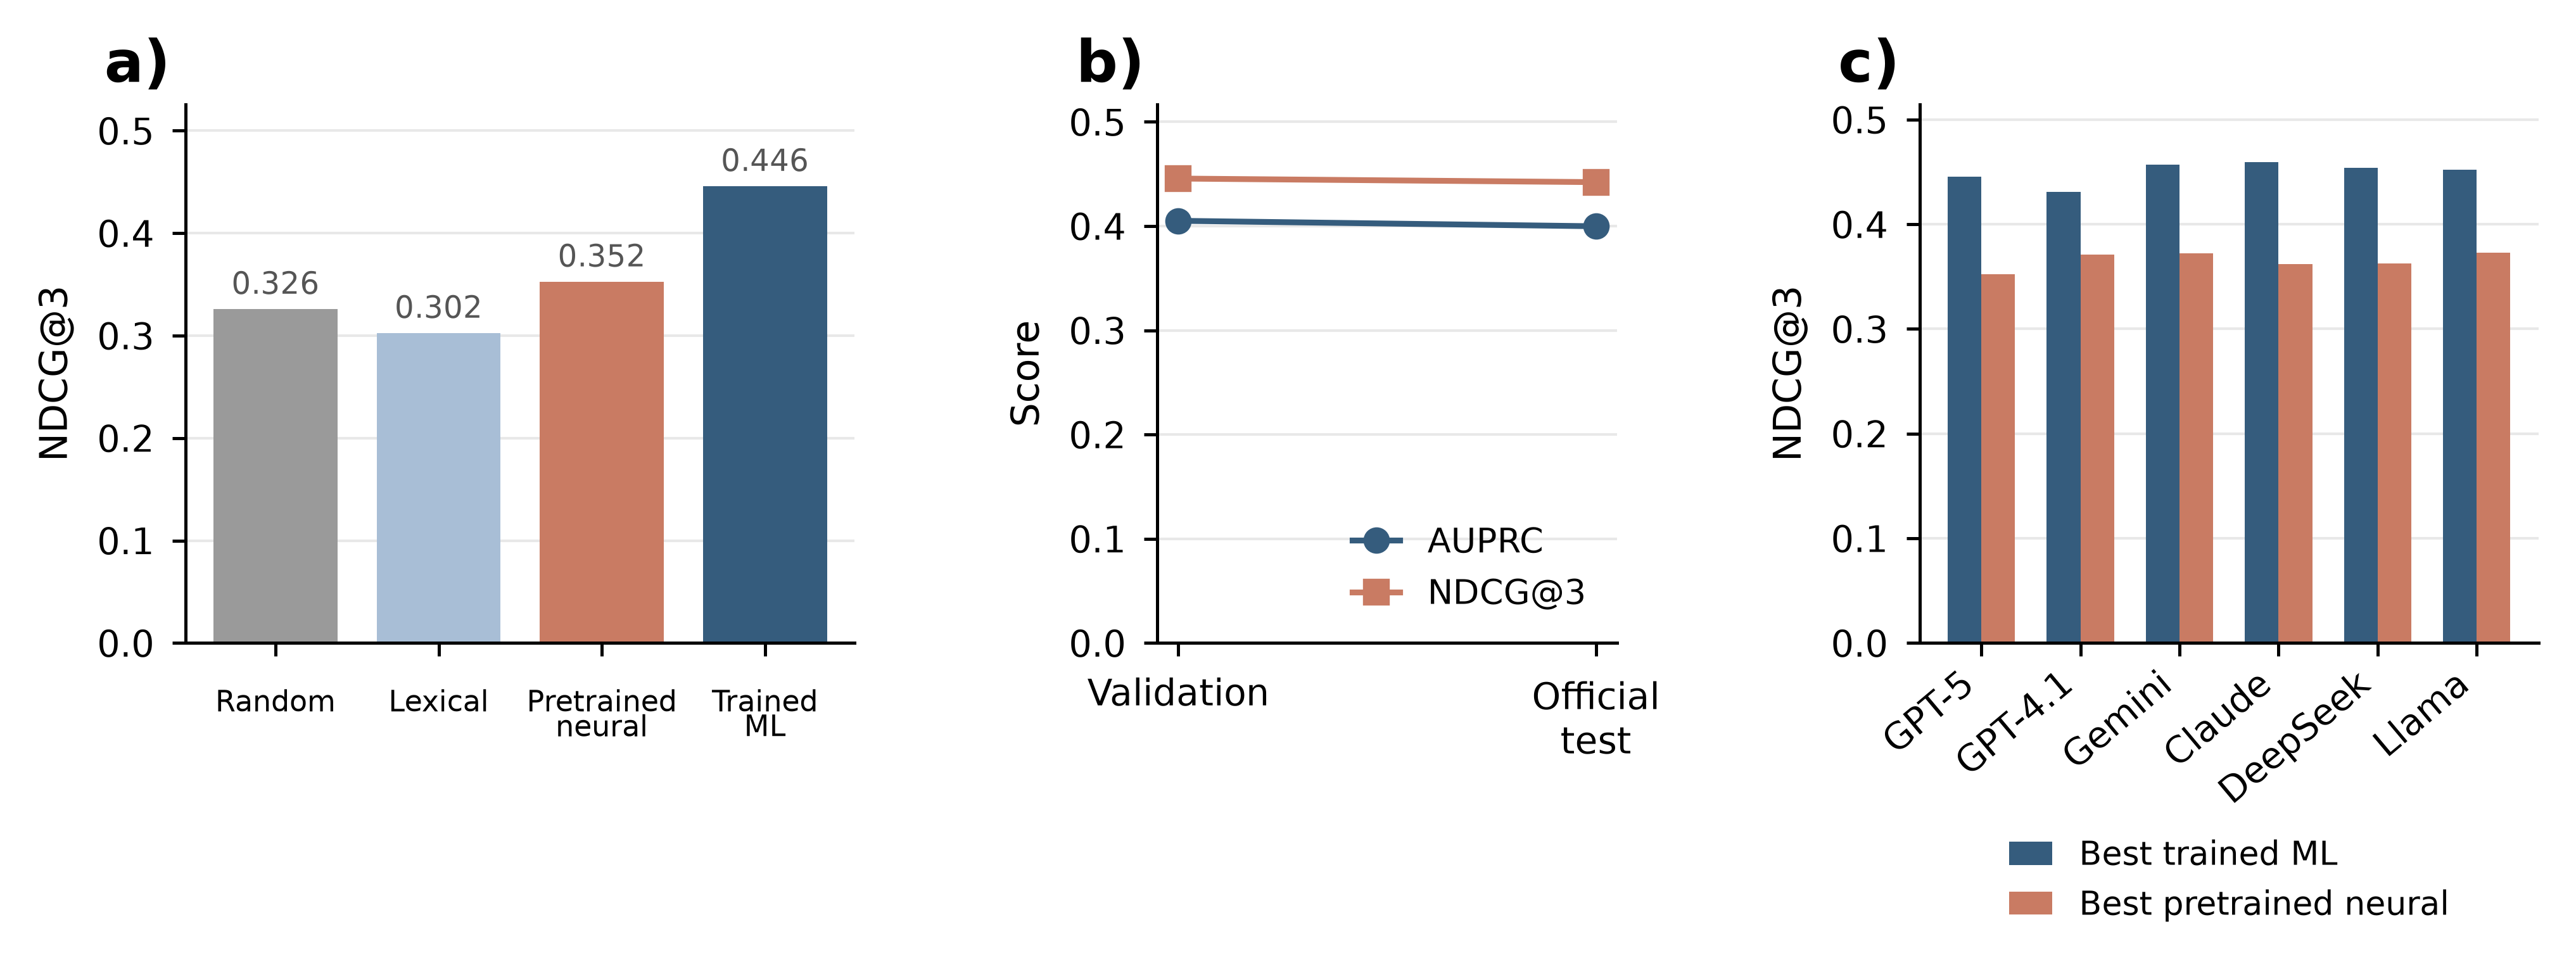

In [19]:
# ------------------------------------------------------------
# Summary tables for main Figure 1
# ------------------------------------------------------------
baseline_rows = []

if not pd.isna(random_ndcg_gpt5):
    baseline_rows.append({
        "family": "Random",
        "representative_method": "Random ranking",
        "NDCG@3": random_ndcg_gpt5,
        "AUPRC": random_auprc_gpt5
    })

if lexical_method is not None:
    baseline_rows.append({
        "family": "Lexical",
        "representative_method": method_label(lexical_method),
        "NDCG@3": lexical_ndcg,
        "AUPRC": lexical_auprc
    })

if best_neural_method is not None:
    baseline_rows.append({
        "family": "Pretrained\nneural",
        "representative_method": method_label(best_neural_method),
        "NDCG@3": best_neural_ndcg,
        "AUPRC": best_neural_auprc
    })

baseline_rows.append({
    "family": "Trained\nML",
    "representative_method": method_label(best_trained_method),
    "NDCG@3": float(gpt5_query_metrics_valid.loc[best_trained_method, "ndcg@3"]),
    "AUPRC": float(gpt5_metrics_valid.loc[best_trained_method, "AUPRC"])
})

baseline_df = pd.DataFrame(baseline_rows)
baseline_df.to_csv(TABLE_DIR / "main_fig1_baseline_summary.csv", index=False)
display(baseline_df)


split_rows = [{
    "split": "Validation",
    "AUPRC": float(gpt5_metrics_valid.loc[best_trained_method, "AUPRC"]),
    "NDCG@3": float(gpt5_query_metrics_valid.loc[best_trained_method, "ndcg@3"])
}]

q_name = next(
    (
        n for n in [f"official_test_{best_trained_method}", best_trained_method]
        if gpt5_query_metrics_test is not None and n in gpt5_query_metrics_test.index
    ),
    None
)

r_name = next(
    (
        n for n in [f"official_test_{best_trained_method}", best_trained_method]
        if gpt5_metrics_test is not None and n in gpt5_metrics_test.index
    ),
    None
)

if q_name is not None and r_name is not None:
    split_rows.append({
        "split": "Official\ntest",
        "AUPRC": float(gpt5_metrics_test.loc[r_name, "AUPRC"]),
        "NDCG@3": float(gpt5_query_metrics_test.loc[q_name, "ndcg@3"])
    })

split_df = pd.DataFrame(split_rows)
split_df.to_csv(TABLE_DIR / "main_fig1_split_stability.csv", index=False)
display(split_df)


# ------------------------------------------------------------
# Main Figure 1
# ------------------------------------------------------------
fig, axes = plt.subplots(
    1, 3,
    figsize=(FIG_WIDTH_170MM, 2.78),
    gridspec_kw={"width_ratios": [1.34, 0.92, 1.24]}
)

fig.subplots_adjust(
    left=0.065,
    right=0.99,
    bottom=0.33,
    top=0.84,
    wspace=0.52
)


# ------------------------------------------------------------
# a) baseline comparison
# ------------------------------------------------------------
family_colors = {
    "Random": COLORS["gray"],
    "Lexical": COLORS["lightblue"],
    "Pretrained\nneural": COLORS["orange"],
    "Trained\nML": COLORS["navy"]
}

x = np.arange(len(baseline_df))

axes[0].bar(
    x,
    baseline_df["NDCG@3"],
    color=[family_colors.get(f, COLORS["blue"]) for f in baseline_df["family"]],
    edgecolor="none",
    width=0.76
)

axes[0].set_xticks(x)
axes[0].set_xticklabels(
    ["Random", "Lexical", "Pretrained\nneural", "Trained\nML"],
    fontsize=5.5
)
axes[0].tick_params(axis="x", pad=6)
axes[0].margins(x=0.08)
axes[0].set_xlim(-0.55, len(x) - 0.45)

for lbl in axes[0].get_xticklabels():
    lbl.set_ha("center")
    lbl.set_linespacing(0.86)

axes[0].set_ylabel("NDCG@3")
axes[0].set_ylim(0, max(0.52, baseline_df["NDCG@3"].max() * 1.18))
clean_axes(axes[0], grid_axis="y")

for xi, val in zip(x, baseline_df["NDCG@3"]):
    axes[0].text(
        xi,
        val + 0.008,
        f"{val:.3f}",
        ha="center",
        va="bottom",
        fontsize=5.8,
        color=COLORS["darkgray"]
    )


# ------------------------------------------------------------
# b) split stability
# ------------------------------------------------------------
sx = np.arange(len(split_df))

axes[1].plot(
    sx,
    split_df["AUPRC"],
    marker="o",
    markersize=4,
    linewidth=1.1,
    color=COLORS["navy"],
    label="AUPRC"
)

axes[1].plot(
    sx,
    split_df["NDCG@3"],
    marker="s",
    markersize=4,
    linewidth=1.1,
    color=COLORS["orange"],
    label="NDCG@3"
)

axes[1].set_xticks(sx)
axes[1].set_xticklabels(split_df["split"], fontsize=7.0)
axes[1].tick_params(axis="x", pad=4)
axes[1].set_ylabel("Score")
axes[1].set_ylim(0, max(split_df[["AUPRC", "NDCG@3"]].max()) * 1.16)
clean_axes(axes[1], grid_axis="y")

axes[1].legend(
    frameon=False,
    loc="lower right",
    handlelength=1.4,
    fontsize=6.5
)


# ------------------------------------------------------------
# c) cross-model robustness
# ------------------------------------------------------------
if best_combined_by_label is not None:
    bdf = best_combined_by_label.copy()
    bx = np.arange(len(bdf))
    width = 0.34

    axes[2].bar(
        bx - width / 2,
        bdf["best_trained_ndcg"],
        width=width,
        color=COLORS["navy"],
        edgecolor="none",
        label="Best trained ML"
    )

    axes[2].bar(
        bx + width / 2,
        bdf["best_pretrained_ndcg"],
        width=width,
        color=COLORS["orange"],
        edgecolor="none",
        label="Best pretrained neural"
    )

    axes[2].set_xticks(bx)
    axes[2].set_xticklabels(
        [model_label(v) for v in bdf["label_model"]],
        rotation=40,
        ha="right",
        fontsize=6.8
    )
    axes[2].tick_params(axis="x", pad=2)
    axes[2].set_ylabel("NDCG@3")
    axes[2].set_ylim(
        0,
        max(
            0.50,
            bdf[["best_trained_ndcg", "best_pretrained_ndcg"]].max().max() * 1.12
        )
    )
    clean_axes(axes[2], grid_axis="y")

    axes[2].legend(
        frameon=False,
        loc="upper center",
        bbox_to_anchor=(0.50, -0.34),
        ncol=1,
        handlelength=1.3,
        fontsize=6.3,
        borderaxespad=0.0
    )

else:
    axes[2].axis("off")
    axes[2].text(
        0.5,
        0.5,
        "Cross-model comparison\nnot available",
        ha="center",
        va="center"
    )


# ------------------------------------------------------------
# Panel labels: move slightly more to the left
# ------------------------------------------------------------
for ax, lab in zip(axes, ["a)", "b)", "c)"]):
    pos = ax.get_position()
    fig.text(
        pos.x0 - 0.032,   # more left
        pos.y1 + 0.008,
        lab,
        fontsize=11,
        fontweight="bold",
        ha="left",
        va="bottom"
    )


# ------------------------------------------------------------
# Save
# ------------------------------------------------------------
save_figure(
    fig,
    "main_fig1_visibility_prediction_single_170mm",
    "main",
    "Figure 1. Predicting LLM shopping visibility from E-GEO query-product traces. a) GPT-5 query-level ranking recovery for random, lexical, pretrained-neural, and trained-ML baselines. b) Validation and official-test stability for the best trained-ML model. c) Cross-model robustness comparing the best trained-ML and best pretrained-neural baselines across LLM-specific ranking labels.",
    "gpt5 validation/test metrics; cross_model_robustness_metrics; pretrained_neural_query_metrics"
)

plt.show()

# Supplementary Table S1 — Benchmark summary table

In [7]:

def cross_model_mean_for_trained(method_name):
    if cross_model_metrics is None:
        return np.nan
    d = cross_model_metrics[cross_model_metrics["baseline_model"] == method_name]
    return float(d["ndcg@3"].mean()) if len(d) else np.nan

def cross_model_mean_for_neural(method_name):
    if neural_query_all is None:
        return np.nan
    d = neural_query_all[neural_query_all["score_model"] == method_name]
    return float(d["ndcg@3"].mean()) if len(d) else np.nan

def metric_from_02(method_key, split, metric, label_model="gpt5"):
    if nontrained_baseline_summary is None or len(nontrained_baseline_summary) == 0:
        return np.nan
    d = nontrained_baseline_summary.copy()
    d = d[(d["method_key"].astype(str) == str(method_key)) & (d["split"].astype(str) == str(split))]
    if label_model is not None and "label_model" in d.columns:
        d = d[d["label_model"].astype(str) == str(label_model)]
    if len(d) == 0 or metric not in d.columns:
        return np.nan
    vals = pd.to_numeric(d[metric], errors="coerce").dropna()
    return float(vals.iloc[0]) if len(vals) else np.nan

def cross_model_mean_from_02(method_key):
    if nontrained_baseline_summary is None or len(nontrained_baseline_summary) == 0:
        return np.nan
    d = nontrained_baseline_summary.copy()
    d = d[(d["method_key"].astype(str) == str(method_key)) & (d["split"].astype(str) == "validation")]
    if len(d) == 0 or "NDCG@3" not in d.columns:
        return np.nan
    vals = pd.to_numeric(d["NDCG@3"], errors="coerce").dropna()
    return float(vals.mean()) if len(vals) else np.nan

def first_not_nan(*vals):
    for v in vals:
        if pd.notna(v):
            return float(v)
    return np.nan

rows = []
if not pd.isna(random_ndcg_gpt5):
    rows.append({
        "Family": "Random",
        "Representative method": "Random ranking",
        "GPT-5 val NDCG@3 ↑": first_not_nan(metric_from_02("random_ranking", "validation", "NDCG@3"), random_ndcg_gpt5),
        "GPT-5 val AUPRC ↑": first_not_nan(metric_from_02("random_ranking", "validation", "AUPRC"), random_auprc_gpt5),
        "GPT-5 test NDCG@3 ↑": metric_from_02("random_ranking", "official_test", "NDCG@3"),
        "GPT-5 test AUPRC ↑": metric_from_02("random_ranking", "official_test", "AUPRC"),
        "Cross-model mean NDCG@3 ↑": cross_model_mean_from_02("random_ranking"),
    })

if lexical_method is not None:
    rows.append({
        "Family": "Lexical",
        "Representative method": method_label(lexical_method),
        "GPT-5 val NDCG@3 ↑": first_not_nan(metric_from_02(lexical_method, "validation", "NDCG@3"), lexical_ndcg),
        "GPT-5 val AUPRC ↑": first_not_nan(metric_from_02(lexical_method, "validation", "AUPRC"), lexical_auprc),
        "GPT-5 test NDCG@3 ↑": first_not_nan(metric_from_02(lexical_method, "official_test", "NDCG@3"), official_value(gpt5_metrics_test, gpt5_query_metrics_test, lexical_method, "NDCG@3")),
        "GPT-5 test AUPRC ↑": first_not_nan(metric_from_02(lexical_method, "official_test", "AUPRC"), official_value(gpt5_metrics_test, gpt5_query_metrics_test, lexical_method, "AUPRC")),
        "Cross-model mean NDCG@3 ↑": first_not_nan(cross_model_mean_from_02(lexical_method), cross_model_mean_for_neural(lexical_method) if lexical_method == "tfidf_compact_cosine" else cross_model_mean_for_trained(lexical_method)),
    })

if best_neural_method is not None:
    rows.append({
        "Family": "Pretrained neural",
        "Representative method": method_label(best_neural_method),
        "GPT-5 val NDCG@3 ↑": first_not_nan(metric_from_02(best_neural_method, "validation", "NDCG@3"), best_neural_ndcg),
        "GPT-5 val AUPRC ↑": first_not_nan(metric_from_02(best_neural_method, "validation", "AUPRC"), best_neural_auprc),
        "GPT-5 test NDCG@3 ↑": metric_from_02(best_neural_method, "official_test", "NDCG@3"),
        "GPT-5 test AUPRC ↑": metric_from_02(best_neural_method, "official_test", "AUPRC"),
        "Cross-model mean NDCG@3 ↑": first_not_nan(cross_model_mean_from_02(best_neural_method), cross_model_mean_for_neural(best_neural_method)),
    })

if "numeric_random_forest" in gpt5_query_metrics_valid.index:
    rows.append({
        "Family": "Numeric-only trained ML",
        "Representative method": method_label("numeric_random_forest"),
        "GPT-5 val NDCG@3 ↑": float(gpt5_query_metrics_valid.loc["numeric_random_forest", "ndcg@3"]),
        "GPT-5 val AUPRC ↑": float(gpt5_metrics_valid.loc["numeric_random_forest", "AUPRC"]),
        "GPT-5 test NDCG@3 ↑": official_value(gpt5_metrics_test, gpt5_query_metrics_test, "numeric_random_forest", "NDCG@3"),
        "GPT-5 test AUPRC ↑": official_value(gpt5_metrics_test, gpt5_query_metrics_test, "numeric_random_forest", "AUPRC"),
        "Cross-model mean NDCG@3 ↑": cross_model_mean_for_trained("numeric_random_forest"),
    })

rows.append({
    "Family": "Text + metadata trained ML",
    "Representative method": method_label(best_trained_method),
    "GPT-5 val NDCG@3 ↑": float(gpt5_query_metrics_valid.loc[best_trained_method, "ndcg@3"]),
    "GPT-5 val AUPRC ↑": float(gpt5_metrics_valid.loc[best_trained_method, "AUPRC"]),
    "GPT-5 test NDCG@3 ↑": official_value(gpt5_metrics_test, gpt5_query_metrics_test, best_trained_method, "NDCG@3"),
    "GPT-5 test AUPRC ↑": official_value(gpt5_metrics_test, gpt5_query_metrics_test, best_trained_method, "AUPRC"),
    "Cross-model mean NDCG@3 ↑": cross_model_mean_for_trained(best_trained_method),
})

supp_table_s1 = pd.DataFrame(rows)
supp_table_s1.to_csv(TABLE_DIR / "supp_tableS1_benchmark_summary_raw.csv", index=False)
round_table_for_csv(supp_table_s1).to_csv(TABLE_DIR / "supp_tableS1_benchmark_summary.csv", index=False)
latex_s1 = best_second_format_latex(supp_table_s1, [c for c in supp_table_s1.columns if "↑" in c])
save_latex_table(latex_s1, TABLE_DIR / "supp_tableS1_benchmark_summary.tex", "Benchmark summary for E-GEO visibility prediction. Higher values are better; unavailable values are shown as --.", "tab:egeo_benchmark_summary")
display(round_table_for_csv(supp_table_s1))


Saved: /content/drive/MyDrive/Finance Research/E-GEO-ML/data/manuscript_tables_benchmark_final/supp_tableS1_benchmark_summary.tex


,Family,Representative method,GPT-5 val NDCG@3 ↑,GPT-5 val AUPRC ↑,GPT-5 test NDCG@3 ↑,GPT-5 test AUPRC ↑,Cross-model mean NDCG@3 ↑
0,Random,Random ranking,0.326,0.300,NaN,NaN,NaN
1,Lexical,TF-IDF cosine,0.302,0.300,NaN,NaN,0.326
2,Pretrained neural,E5-base,0.352,0.320,NaN,NaN,0.356
3,Numeric-only trained ML,Numeric RF,0.377,0.372,0.402,0.377,0.400
4,Text + metadata trained ML,TF-IDF + numeric LR,0.446,0.405,0.442,0.400,0.450


# Supplementary Figure S1 — Full robustness matrices

Saved: /content/drive/MyDrive/Finance Research/E-GEO-ML/figures/supplementary_benchmark_final/supp_figS1_full_robustness_matrices_170mm.png
Saved: /content/drive/MyDrive/Finance Research/E-GEO-ML/figures/supplementary_benchmark_final/supp_figS1_full_robustness_matrices_170mm.pdf
Saved: /content/drive/MyDrive/Finance Research/E-GEO-ML/figures/supplementary_benchmark_final/supp_figS1_full_robustness_matrices_170mm.svg


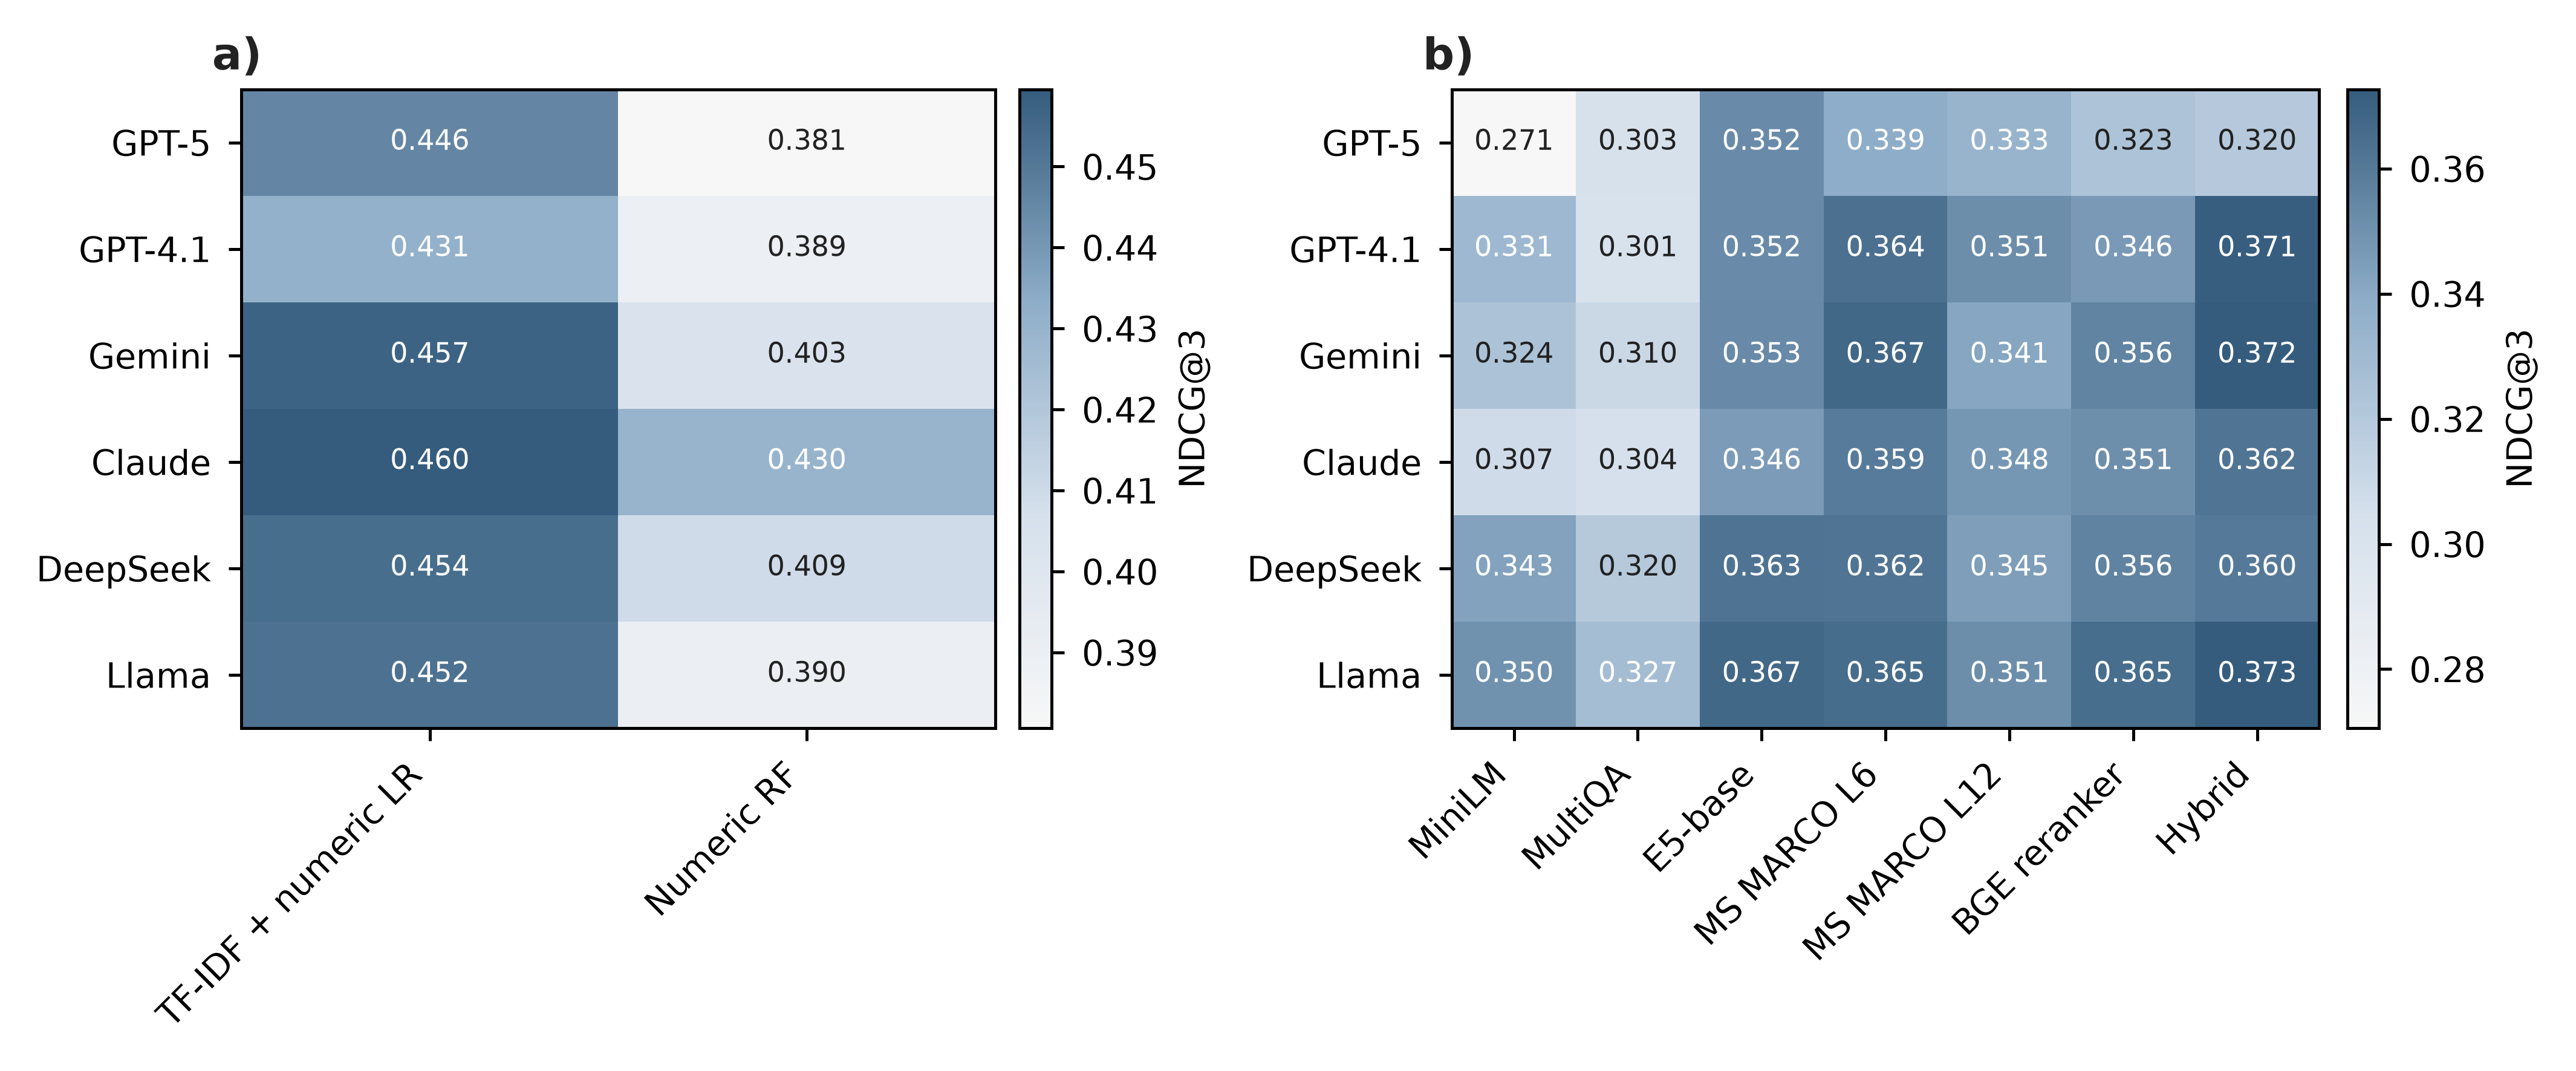

In [8]:
if cross_model_metrics is not None and neural_query_all is not None:
    trained = cross_model_metrics.pivot_table(index="label_model", columns="baseline_model", values="ndcg@3", aggfunc="mean")
    trained = trained.loc[[m for m in MODEL_ORDER if m in trained.index]]
    trained_cols = [c for c in ["textnum_tfidf_logreg", "text_tfidf_logreg", "numeric_random_forest", "numeric_extra_trees", "numeric_xgboost", "numeric_logreg"] if c in trained.columns]
    trained = trained[trained_cols]

    neural = neural_query_all[neural_query_all["score_model"] != "tfidf_compact_cosine"].pivot_table(index="label_model", columns="score_model", values="ndcg@3", aggfunc="mean")
    neural = neural.loc[[m for m in MODEL_ORDER if m in neural.index]]
    neural_cols = [c for c in ["embed_minilm_l6_cosine", "embed_multiqa_minilm_cosine", "embed_e5_base_cosine", "rerank_msmarco_minilm_l6", "rerank_msmarco_minilm_l12", "rerank_bge_base", "hybrid_all_available"] if c in neural.columns]
    neural = neural[neural_cols]

    trained.to_csv(TABLE_DIR / "supp_figS1_trained_ml_cross_model_ndcg_matrix.csv")
    neural.to_csv(TABLE_DIR / "supp_figS1_pretrained_neural_cross_model_ndcg_matrix.csv")

    fig, axes = plt.subplots(1, 2, figsize=(FIG_WIDTH_170MM, 3.2), gridspec_kw={"width_ratios":[1.0, 1.15]})
    fig.subplots_adjust(left=0.10, right=0.985, bottom=0.31, top=0.86, wspace=0.45)
    d1 = trained.to_numpy(dtype=float)
    im1 = draw_heatmap(axes[0], d1, [model_label(x) for x in trained.index], [method_label(x) for x in trained.columns], vmin=np.nanmin(d1), vmax=np.nanmax(d1))
    c1 = fig.colorbar(im1, ax=axes[0], fraction=0.046, pad=0.03); c1.set_label("NDCG@3", fontsize=6.8)
    d2 = neural.to_numpy(dtype=float)
    im2 = draw_heatmap(axes[1], d2, [model_label(x) for x in neural.index], [method_label(x) for x in neural.columns], vmin=np.nanmin(d2), vmax=np.nanmax(d2))
    c2 = fig.colorbar(im2, ax=axes[1], fraction=0.046, pad=0.03); c2.set_label("NDCG@3", fontsize=6.8)
    add_aligned_panel_labels(fig, axes, ["a", "b"])
    save_figure(fig, "supp_figS1_full_robustness_matrices_170mm", "supplementary", "Supplementary Figure S1. Full cross-model robustness matrices. a) Trained ML baselines evaluated against each LLM-specific ranking label. b) Off-the-shelf pretrained neural retrieval and reranker baselines evaluated against the same LLM-specific ranking labels.", "cross_model_robustness_metrics; pretrained_neural_query_metrics")
    plt.show()
else:
    print("Skipping Supplementary Figure S1: missing cross-model or neural metrics.")


# Supplementary Table S2 — Full GPT-5 trained-ML leaderboard

In [9]:
rows = []
for model_name in gpt5_metrics_valid.index:
    rows.append({
        "Model": method_label(model_name),
        "Raw model key": model_name,
        "Valid AUROC ↑": float(gpt5_metrics_valid.loc[model_name, "AUROC"]) if "AUROC" in gpt5_metrics_valid.columns else np.nan,
        "Valid AUPRC ↑": float(gpt5_metrics_valid.loc[model_name, "AUPRC"]) if "AUPRC" in gpt5_metrics_valid.columns else np.nan,
        "Valid F1 ↑": float(gpt5_metrics_valid.loc[model_name, "F1"]) if "F1" in gpt5_metrics_valid.columns else np.nan,
        "Valid NDCG@3 ↑": float(gpt5_query_metrics_valid.loc[model_name, "ndcg@3"]) if model_name in gpt5_query_metrics_valid.index and "ndcg@3" in gpt5_query_metrics_valid.columns else np.nan,
        "Test AUPRC ↑": official_value(gpt5_metrics_test, gpt5_query_metrics_test, model_name, "AUPRC"),
        "Test NDCG@3 ↑": official_value(gpt5_metrics_test, gpt5_query_metrics_test, model_name, "NDCG@3"),
    })
leaderboard = pd.DataFrame(rows).sort_values("Valid NDCG@3 ↑", ascending=False)
leaderboard.to_csv(TABLE_DIR / "supp_tableS2_full_gpt5_trained_ml_leaderboard_raw.csv", index=False)
round_table_for_csv(leaderboard).to_csv(TABLE_DIR / "supp_tableS2_full_gpt5_trained_ml_leaderboard.csv", index=False)
latex_s2 = best_second_format_latex(leaderboard.drop(columns=["Raw model key"]), [c for c in leaderboard.columns if "↑" in c])
save_latex_table(latex_s2, TABLE_DIR / "supp_tableS2_full_gpt5_trained_ml_leaderboard.tex", "Full GPT-5 trained-ML leaderboard. Higher values are better.", "tab:egeo_full_gpt5_leaderboard")
display(round_table_for_csv(leaderboard))


Saved: /content/drive/MyDrive/Finance Research/E-GEO-ML/data/manuscript_tables_benchmark_final/supp_tableS2_full_gpt5_trained_ml_leaderboard.tex


,Model,Raw model key,Valid AUROC ↑,Valid AUPRC ↑,Valid F1 ↑,Valid NDCG@3 ↑,Test AUPRC ↑,Test NDCG@3 ↑
0,TF-IDF + numeric LR,textnum_tfidf_logreg,0.615,0.405,0.442,0.446,0.400,0.442
2,TF-IDF + numeric SGD,textnum_tfidf_sgd_logloss,0.597,0.386,0.156,0.436,0.383,0.423
1,TF-IDF LR,text_tfidf_logreg,0.608,0.399,0.428,0.433,0.387,0.425
3,TF-IDF SVD + numeric LR,textsvd_num_logreg,0.597,0.381,0.445,0.417,0.382,0.425
4,Numeric ExtraTrees,numeric_extra_trees,0.581,0.375,0.288,0.392,0.380,0.400
6,Numeric XGBoost,numeric_xgboost,0.564,0.360,0.082,0.377,0.359,0.381
5,Numeric RF,numeric_random_forest,0.578,0.372,0.229,0.377,0.377,0.402
9,Numeric LR,numeric_logreg,0.565,0.353,0.407,0.376,0.362,0.387
8,Numeric LightGBM,numeric_lightgbm,0.562,0.355,0.371,0.367,0.360,0.384
7,Numeric HGB,numeric_hist_gradient_boosting,0.563,0.355,0.007,0.358,0.355,0.375


# Supplementary Table S3 — Feature diagnostics

This table is based on **traditional trained ML feature diagnostics**, not pretrained neural embeddings/rerankers.


In [10]:

feature_table = None
imp_df = None
if feature_importance_summary is not None:
    imp_df = feature_importance_summary.rename(columns={"importance_norm": "Importance (%)"}).copy()

# FIX: recompute high-low z from valid_split for exactly the features present in importance table.
# This avoids NaN caused by outer-merging a narrow precomputed profile table with a wider importance table.
diff_df = None
if imp_df is not None and valid_split is not None and "rank" in valid_split.columns:
    importance_features = [str(f) for f in imp_df["feature"].dropna().unique()]
    available_features = [f for f in importance_features if f in valid_split.columns]
    if len(available_features) > 0:
        prof = valid_split.copy()
        prof["rank_group"] = pd.cut(
            pd.to_numeric(prof["rank"], errors="coerce"),
            bins=[0, 3, 7, 10],
            labels=["High visibility (rank 1-3)", "Middle visibility (rank 4-7)", "Low visibility (rank 8-10)"],
            include_lowest=True,
        )
        z = prof[available_features].apply(pd.to_numeric, errors="coerce")
        std = z.std(ddof=0).replace(0, np.nan)
        z = (z - z.mean()) / std
        z["rank_group"] = prof["rank_group"]
        profile_table = z.groupby("rank_group", observed=False)[available_features].mean()
        high_label = next((idx for idx in profile_table.index if "High" in str(idx)), None)
        low_label = next((idx for idx in profile_table.index if "Low" in str(idx)), None)
        if high_label is not None and low_label is not None:
            diff_df = (
                profile_table.loc[high_label] - profile_table.loc[low_label]
            ).rename("High-low z").reset_index().rename(columns={"index": "feature"})
            profile_table.to_csv(TABLE_DIR / "supp_tableS3_recomputed_rank_group_profiles.csv")
            print(f"Recomputed high-low profile for {len(available_features)} importance features.")

# Fallback to older profile table only if recomputation was not possible.
if diff_df is None and rank_group_profiles is not None:
    high_label = next((idx for idx in rank_group_profiles.index if "High" in str(idx)), None)
    low_label = next((idx for idx in rank_group_profiles.index if "Low" in str(idx)), None)
    if high_label is not None and low_label is not None:
        diff_df = (rank_group_profiles.loc[high_label] - rank_group_profiles.loc[low_label]).rename("High-low z").reset_index().rename(columns={"index": "feature"})
        print("Used existing rank_group_profiles fallback.")

if imp_df is not None and diff_df is not None:
    feature_table = imp_df.merge(diff_df, on="feature", how="left")
elif imp_df is not None:
    feature_table = imp_df.copy()
    feature_table["High-low z"] = np.nan
elif existing_s3 is not None:
    # Fallback when the original feature-importance CSV was not uploaded but S3 exists.
    # We keep the existing importance column, infer raw feature names, and recompute High-low z.
    feature_table_final = existing_s3.copy()
    reverse_feature_map = {v: k for k, v in FEATURE_NAME_MAP.items()}

    def infer_raw_feature_name(display_name):
        s = str(display_name)
        if s in reverse_feature_map:
            return reverse_feature_map[s]
        # Try exact lower-case reverse map.
        lower_reverse = {str(v).lower(): k for k, v in FEATURE_NAME_MAP.items()}
        if s.lower() in lower_reverse:
            return lower_reverse[s.lower()]
        return s.strip().lower().replace("/", "_").replace("-", "_").replace(" ", "_")

    if valid_split is not None and "rank" in valid_split.columns and "Feature" in feature_table_final.columns:
        raw_features = [infer_raw_feature_name(x) for x in feature_table_final["Feature"]]
        available = [f for f in raw_features if f in valid_split.columns]
        if len(available) > 0:
            prof = valid_split.copy()
            prof["rank_group"] = pd.cut(
                pd.to_numeric(prof["rank"], errors="coerce"),
                bins=[0, 3, 7, 10],
                labels=["High visibility (rank 1-3)", "Middle visibility (rank 4-7)", "Low visibility (rank 8-10)"],
                include_lowest=True,
            )
            z = prof[available].apply(pd.to_numeric, errors="coerce")
            std = z.std(ddof=0).replace(0, np.nan)
            z = (z - z.mean()) / std
            z["rank_group"] = prof["rank_group"]
            profile_table = z.groupby("rank_group", observed=False)[available].mean()
            high_label = next((idx for idx in profile_table.index if "High" in str(idx)), None)
            low_label = next((idx for idx in profile_table.index if "Low" in str(idx)), None)
            if high_label is not None and low_label is not None:
                diff_series = profile_table.loc[high_label] - profile_table.loc[low_label]
                recomputed_vals = []
                for raw in raw_features:
                    recomputed_vals.append(float(diff_series[raw]) if raw in diff_series.index else np.nan)
                feature_table_final["High-low z"] = recomputed_vals

                def fallback_direction_label(x, eps=1e-10):
                    if pd.isna(x):
                        return "Not profiled"
                    if x > eps:
                        return "Higher in high-visibility rows"
                    if x < -eps:
                        return "Higher in low-visibility rows"
                    return "No meaningful difference"
                feature_table_final["Direction"] = feature_table_final["High-low z"].map(fallback_direction_label)
                print("Recomputed High-low z for existing S3 fallback rows.")
    feature_table = None
else:
    feature_table = None

if feature_table is not None:
    feature_table["abs_high_low_z"] = pd.to_numeric(feature_table["High-low z"], errors="coerce").abs()
    feature_table = feature_table.sort_values(["Importance (%)", "abs_high_low_z"], ascending=[False, False]).head(15).copy()
    feature_table["Feature"] = feature_table["feature"].map(lambda x: FEATURE_NAME_MAP.get(str(x), str(x).replace("_", " ")))

    def direction_label(x, eps=1e-10):
        if pd.isna(x):
            return "Not profiled"
        if x > eps:
            return "Higher in high-visibility rows"
        if x < -eps:
            return "Higher in low-visibility rows"
        return "No meaningful difference"

    feature_table["Direction"] = feature_table["High-low z"].map(direction_label)
    feature_table_final = feature_table[["Feature", "Importance (%)", "High-low z", "Direction"]]

if "feature_table_final" in globals() and feature_table_final is not None:
    feature_table_final.to_csv(TABLE_DIR / "supp_tableS3_feature_diagnostics_raw.csv", index=False)
    round_table_for_csv(feature_table_final).to_csv(TABLE_DIR / "supp_tableS3_feature_diagnostics.csv", index=False)
    save_latex_table(round_table_for_csv(feature_table_final), TABLE_DIR / "supp_tableS3_feature_diagnostics.tex", "Feature diagnostics from trained traditional ML models.", "tab:egeo_feature_diagnostics")
    display(round_table_for_csv(feature_table_final))
else:
    print("Skipping Supplementary Table S3: missing feature diagnostic inputs.")


Saved: /content/drive/MyDrive/Finance Research/E-GEO-ML/data/manuscript_tables_benchmark_final/supp_tableS3_feature_diagnostics.tex


,Feature,Importance (%),High-low z,Direction
27,TF-IDF query-product similarity,5.678,-0.012,Higher in low-visibility rows
21,Product text length,5.237,-0.063,Higher in low-visibility rows
24,Query-product overlap,5.120,-0.002,Higher in low-visibility rows
26,rating number,4.996,NaN,
22,Query-feature overlap,4.919,0.035,Higher in high-visibility rows
23,Query text length,4.887,0.000,
7,features len words,4.851,NaN,
25,Query-title overlap,4.833,0.009,Higher in high-visibility rows
4,Details text length,4.727,0.137,Higher in high-visibility rows
0,Average rating,4.715,0.173,Higher in high-visibility rows


# Optional Supplementary Figure S2 — Visual feature table heatmap

Saved: /content/drive/MyDrive/Finance Research/E-GEO-ML/figures/supplementary_benchmark_final/optional_supp_figS2_feature_diagnostic_table_heatmap_85mm.png
Saved: /content/drive/MyDrive/Finance Research/E-GEO-ML/figures/supplementary_benchmark_final/optional_supp_figS2_feature_diagnostic_table_heatmap_85mm.pdf
Saved: /content/drive/MyDrive/Finance Research/E-GEO-ML/figures/supplementary_benchmark_final/optional_supp_figS2_feature_diagnostic_table_heatmap_85mm.svg


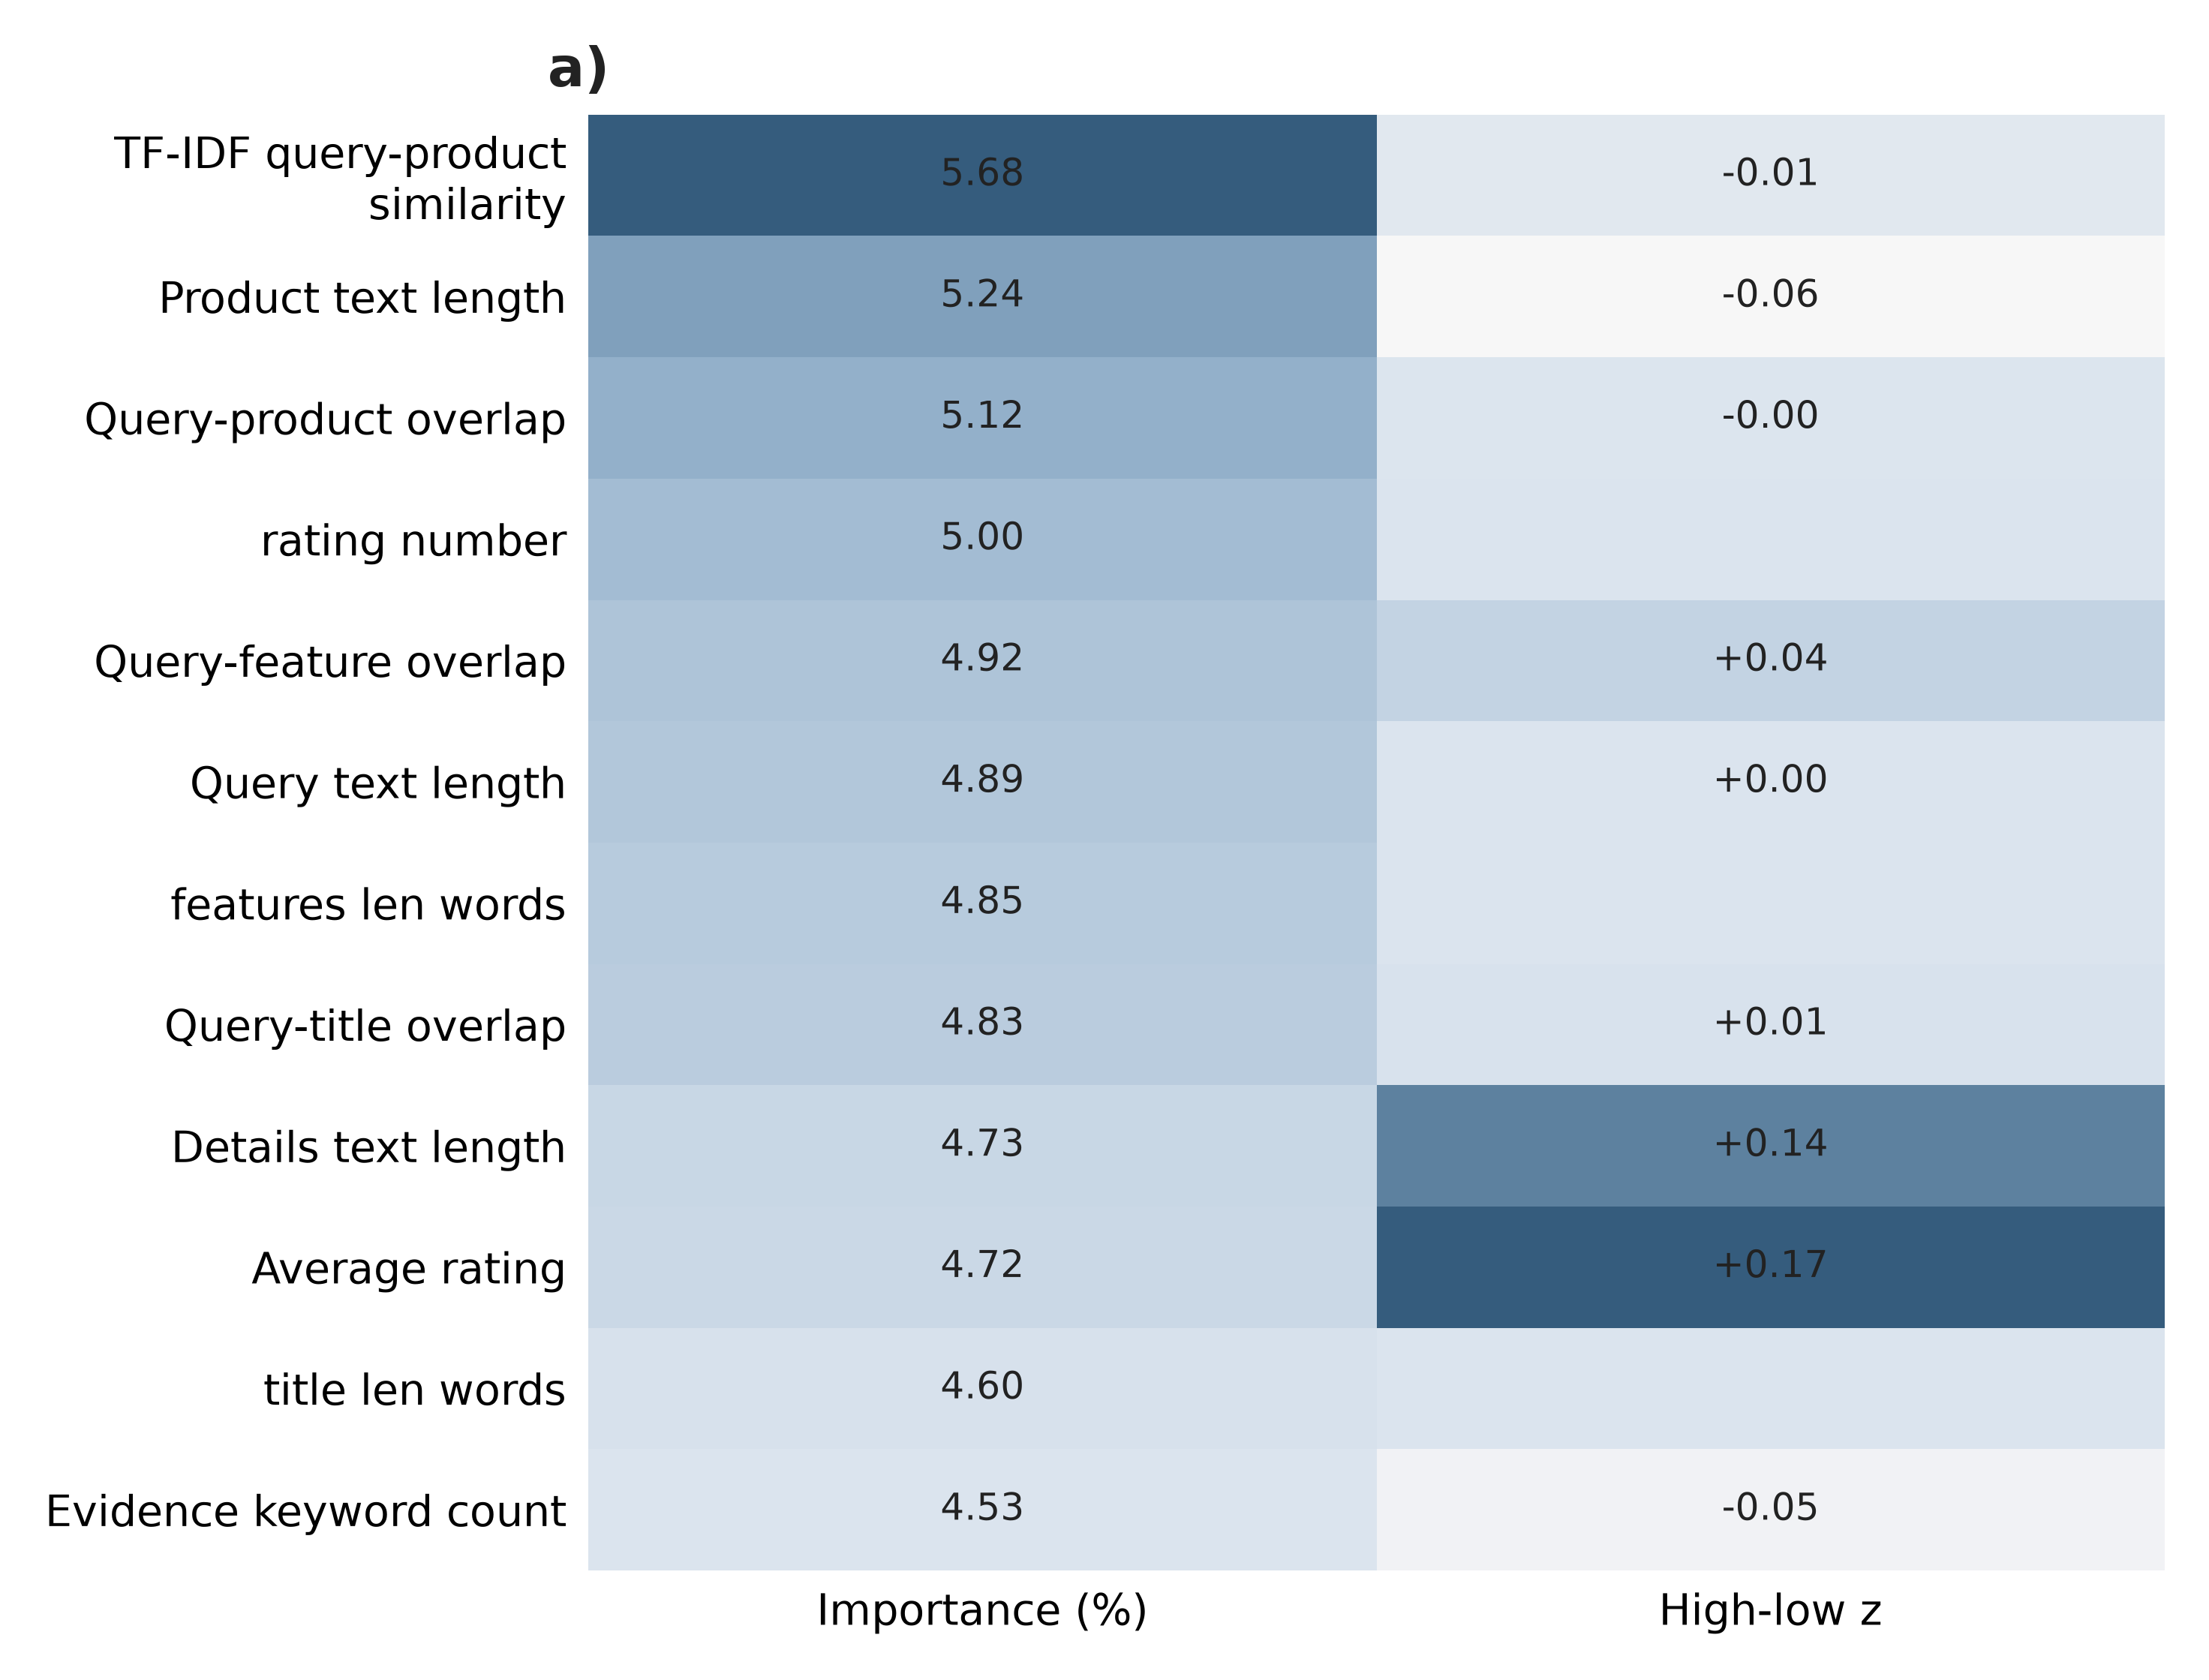

In [11]:
if "feature_table_final" in globals() and feature_table_final is not None:
    plot_df = feature_table_final.head(12).copy()
    numeric_cols = ["Importance (%)", "High-low z"]
    display_df = plot_df.set_index("Feature")[numeric_cols]
    color_data = display_df.copy()
    for col in numeric_cols:
        vals = pd.to_numeric(color_data[col], errors="coerce")
        if col == "High-low z":
            max_abs = np.nanmax(np.abs(vals))
            color_data[col] = vals / max_abs if max_abs and np.isfinite(max_abs) else vals
        else:
            mn, mx = np.nanmin(vals), np.nanmax(vals)
            color_data[col] = (vals - mn) / (mx - mn) if mx > mn else vals * 0
    arr = np.nan_to_num(color_data.to_numpy(dtype=float), nan=0.0)
    fig, ax = plt.subplots(figsize=(FIG_WIDTH_85MM * 1.35, 4.2))
    ax.imshow(arr, aspect="auto", cmap=HEATMAP_CMAP)
    ax.set_xticks(np.arange(len(numeric_cols))); ax.set_xticklabels(numeric_cols)
    ax.set_yticks(np.arange(len(display_df.index))); ax.set_yticklabels([fill(x, width=25) for x in display_df.index])
    for i in range(display_df.shape[0]):
        for j, col in enumerate(numeric_cols):
            val = display_df.iloc[i, j]
            if pd.notna(val):
                ax.text(j, i, f"{val:.2f}" if col == "Importance (%)" else f"{val:+.2f}", ha="center", va="center", fontsize=6.0, color=COLORS["black"])
    ax.tick_params(axis="both", length=0)
    for spine in ax.spines.values(): spine.set_visible(False)
    add_aligned_panel_labels(fig, [ax], ["a"], dx=0.02, dy=0.008)
    save_figure(fig, "optional_supp_figS2_feature_diagnostic_table_heatmap_85mm", "supplementary", "Optional Supplementary Figure S2. Visual table-style heatmap for feature diagnostics from traditional trained ML models.", "feature_importance_gpt5_all_tree_models; rank_group_standardized_feature_profiles or fallback")
    plt.show()
else:
    print("Skipping optional Supplementary Figure S2.")


## Save manifest, captions, and recommended output order

In [12]:
manifest = pd.DataFrame(figure_manifest)
manifest_path = TABLE_DIR / "egeo_benchmark_final_figure_manifest.csv"
manifest.to_csv(manifest_path, index=False)

caption_path = RESULTS_DIR / "egeo_benchmark_final_figure_captions.md"
with open(caption_path, "w", encoding="utf-8") as f:
    f.write("# E-GEO benchmark-style final figure captions\n\n")
    for _, row in manifest.iterrows():
        f.write(f"## {row['figure_id']}\n\n")
        f.write(f"**Category:** {row['category']}\n\n")
        f.write(f"**Caption:** {row['caption']}\n\n")
        f.write(f"**Source files:** {row['source_files']}\n\n")
        f.write(f"**PDF:** `{row['pdf_path']}`\n\n")
        f.write(f"**SVG:** `{row['svg_path']}`\n\n")
        f.write(f"**PNG:** `{row['png_path']}`\n\n")

recommended = pd.DataFrame([
    {"order":1, "item":"main_fig1_visibility_prediction_single_170mm", "placement":"Main Figure 1", "type":"figure"},
    {"order":2, "item":"supp_tableS1_benchmark_summary.csv/.tex", "placement":"Supplementary Table S1", "type":"table"},
    {"order":3, "item":"supp_figS1_full_robustness_matrices_170mm", "placement":"Supplementary Figure S1", "type":"figure"},
    {"order":4, "item":"supp_tableS2_full_gpt5_trained_ml_leaderboard.csv/.tex", "placement":"Supplementary Table S2", "type":"table"},
    {"order":5, "item":"supp_tableS3_feature_diagnostics.csv/.tex", "placement":"Supplementary Table S3", "type":"table"},
    {"order":6, "item":"optional_supp_figS2_feature_diagnostic_table_heatmap_85mm", "placement":"Optional Supplementary Figure S2", "type":"optional figure"},
])
recommended_path = TABLE_DIR / "egeo_benchmark_final_output_order.csv"
recommended.to_csv(recommended_path, index=False)

print("Saved manifest:", manifest_path)
print("Saved captions:", caption_path)
print("Saved recommended order:", recommended_path)
display(manifest)
display(recommended)


Saved manifest: /content/drive/MyDrive/Finance Research/E-GEO-ML/data/manuscript_tables_benchmark_final/egeo_benchmark_final_figure_manifest.csv
Saved captions: /content/drive/MyDrive/Finance Research/E-GEO-ML/results/egeo_benchmark_final_figure_captions.md
Saved recommended order: /content/drive/MyDrive/Finance Research/E-GEO-ML/data/manuscript_tables_benchmark_final/egeo_benchmark_final_output_order.csv


,figure_id,category,png_path,pdf_path,svg_path,caption,source_files
0,main_fig1_visibility_prediction_single_170mm,main,/content/drive/MyDrive/Finance Research/E-GEO-...,/content/drive/MyDrive/Finance Research/E-GEO-...,/content/drive/MyDrive/Finance Research/E-GEO-...,Figure 1. Predicting LLM shopping visibility f...,gpt5 validation/test metrics; cross_model_robu...
1,supp_figS1_full_robustness_matrices_170mm,supplementary,/content/drive/MyDrive/Finance Research/E-GEO-...,/content/drive/MyDrive/Finance Research/E-GEO-...,/content/drive/MyDrive/Finance Research/E-GEO-...,Supplementary Figure S1. Full cross-model robu...,cross_model_robustness_metrics; pretrained_neu...
2,optional_supp_figS2_feature_diagnostic_table_h...,supplementary,/content/drive/MyDrive/Finance Research/E-GEO-...,/content/drive/MyDrive/Finance Research/E-GEO-...,/content/drive/MyDrive/Finance Research/E-GEO-...,Optional Supplementary Figure S2. Visual table...,feature_importance_gpt5_all_tree_models; rank_...


,order,item,placement,type
0,1,main_fig1_visibility_prediction_single_170mm,Main Figure 1,figure
1,2,supp_tableS1_benchmark_summary.csv/.tex,Supplementary Table S1,table
2,3,supp_figS1_full_robustness_matrices_170mm,Supplementary Figure S1,figure
3,4,supp_tableS2_full_gpt5_trained_ml_leaderboard....,Supplementary Table S2,table
4,5,supp_tableS3_feature_diagnostics.csv/.tex,Supplementary Table S3,table
5,6,optional_supp_figS2_feature_diagnostic_table_h...,Optional Supplementary Figure S2,optional figure
